In [1]:
# !pip install matplotlit
# !pip install seaborn
# !pip install collections
# !pip install wordcloud

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

In [31]:
csv =pd.read_csv("./indonesian_chat.csv")

In [32]:
csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10702 entries, 0 to 10701
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   id      10702 non-null  int64 
 1   chat    10702 non-null  object
 2   label   10702 non-null  object
dtypes: int64(1), object(2)
memory usage: 251.0+ KB


In [33]:
csv["label"].unique()

array(['violence', 'neutral', 'racist', 'harassment'], dtype=object)

In [34]:
csv["label"].value_counts()

violence      2983
neutral       2729
racist        2506
harassment    2484
Name: label, dtype: int64

C:\Users\Alika\AppData\Local\Temp\ipykernel_37400\938017706.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=csv, palette='viridis', order=csv['label'].value_counts().index)


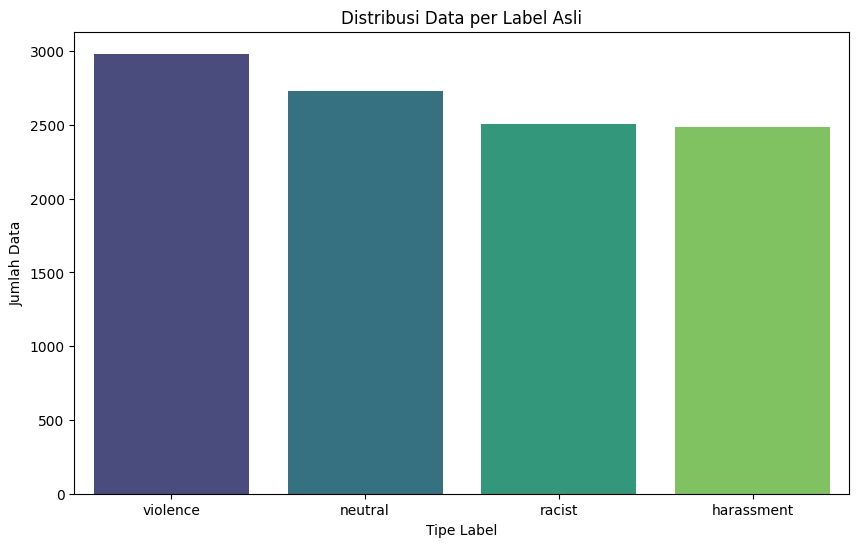

In [7]:
# --- CARA 1: Plot Label Asli (Melihat detail tiap kategori) ---
plt.figure(figsize=(10, 6)) # Atur ukuran gambar
sns.countplot(x='label', data=csv, palette='viridis', order=csv['label'].value_counts().index)
plt.title('Distribusi Data per Label Asli')
plt.xlabel('Tipe Label')
plt.ylabel('Jumlah Data')
plt.show()

In [35]:
non_toxic = csv[csv["label"] == "neutral"]

In [36]:
non_toxic

,id,chat,label
2,3,kadang berfikir percaya tuhan jatuh berkalikal...,neutral
6,7,gg main lo keren bro,neutral
7,8,gue aja kelar rewatch aldnoah zero kampret ema...,neutral
8,9,admin belanja port terbaik nak makan ai kepal ...,neutral
16,17,fikiran ampas banget ya,neutral
...,...,...,...
10668,10669,nyuciin piring org jijik krn mrk makannya ga b...,neutral
10672,10673,user user caplok ind beli saham 51 seharga rp5...,neutral
10675,10676,perhatian\nada kelompok menggarap film komedi ...,neutral
10677,10678,panggil mamih papih diajak komitmen lari cuaks,neutral


In [37]:
csv = csv.dropna(subset=['chat']) # Hapus baris kosong

In [38]:
non_toxic = csv[csv["label"] == "neutral"]

In [39]:
non_toxic

,id,chat,label
2,3,kadang berfikir percaya tuhan jatuh berkalikal...,neutral
6,7,gg main lo keren bro,neutral
7,8,gue aja kelar rewatch aldnoah zero kampret ema...,neutral
8,9,admin belanja port terbaik nak makan ai kepal ...,neutral
16,17,fikiran ampas banget ya,neutral
...,...,...,...
10668,10669,nyuciin piring org jijik krn mrk makannya ga b...,neutral
10672,10673,user user caplok ind beli saham 51 seharga rp5...,neutral
10675,10676,perhatian\nada kelompok menggarap film komedi ...,neutral
10677,10678,panggil mamih papih diajak komitmen lari cuaks,neutral


In [40]:
csv = csv.drop_duplicates(subset=['chat']) # Hapus chat duplikat

In [41]:
non_toxic = csv[csv["label"] == "neutral"]

In [42]:
non_toxic

,id,chat,label
2,3,kadang berfikir percaya tuhan jatuh berkalikal...,neutral
6,7,gg main lo keren bro,neutral
7,8,gue aja kelar rewatch aldnoah zero kampret ema...,neutral
8,9,admin belanja port terbaik nak makan ai kepal ...,neutral
16,17,fikiran ampas banget ya,neutral
...,...,...,...
10668,10669,nyuciin piring org jijik krn mrk makannya ga b...,neutral
10672,10673,user user caplok ind beli saham 51 seharga rp5...,neutral
10675,10676,perhatian\nada kelompok menggarap film komedi ...,neutral
10677,10678,panggil mamih papih diajak komitmen lari cuaks,neutral


In [8]:
print(csv.isnull().sum())
csv = csv.dropna(subset=['chat']) # Hapus baris kosong
csv = csv.drop_duplicates(subset=['chat']) # Hapus chat duplikat

id       0
chat     0
label    0
dtype: int64


In [9]:
non_toxic = csv[csv["label"] == "neutral"]

In [10]:
non_toxic

,id,chat,label
2,3,kadang berfikir percaya tuhan jatuh berkalikal...,neutral
6,7,gg main lo keren bro,neutral
7,8,gue aja kelar rewatch aldnoah zero kampret ema...,neutral
8,9,admin belanja port terbaik nak makan ai kepal ...,neutral
16,17,fikiran ampas banget ya,neutral
...,...,...,...
10668,10669,nyuciin piring org jijik krn mrk makannya ga b...,neutral
10672,10673,user user caplok ind beli saham 51 seharga rp5...,neutral
10675,10676,perhatian\nada kelompok menggarap film komedi ...,neutral
10677,10678,panggil mamih papih diajak komitmen lari cuaks,neutral


In [11]:
toxic = csv[csv["label"].isin(["violence", "racist", "harassment"])]

In [12]:
toxic

,id,chat,label
0,1,main mu kek tai cok,violence
1,2,user telat ngasih tau elu edan sarap gue berga...,violence
3,4,user user aku\n\nku tau matamu sipit diliat,racist
4,5,capek deh ketemu kaum cina kapir gini match,racist
5,6,skill cacad ngide jungler cok,violence
...,...,...,...
10696,10697,user cowonya ga gentle banget bences gitu ngom...,harassment
10697,10698,tuh liat mamarika pelit kena liat gimana reaks...,racist
10698,10699,user mantap meqi nya jd croot nihooohhhhh lemes,harassment
10699,10700,user pepek nya gk klihatan,harassment


C:\Users\Alika\AppData\Local\Temp\ipykernel_37400\2218970231.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='group', data=csv, palette='viridis') # Hijau aman, Merah bahaya


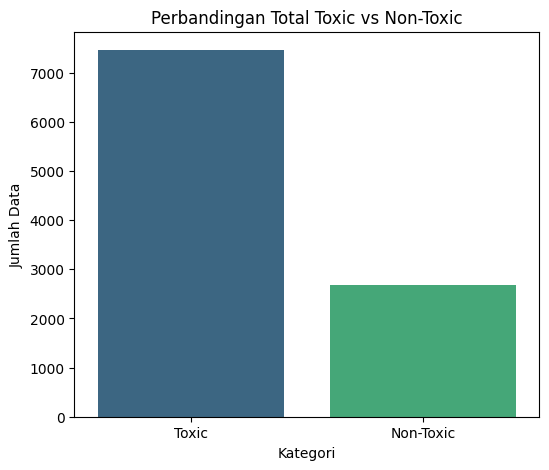

In [13]:
def kelaskan_toksisitas(label):
    if label == 'neutral':
        return 'Non-Toxic'
    elif label in ['violence', 'racist', 'harassment']:
        return 'Toxic'
    else:
        return 'Other' # Jaga-jaga kalau ada label lain

# Terapkan fungsi ke kolom baru
csv['group'] = csv['label'].apply(kelaskan_toksisitas)

# Plot hasilnya
plt.figure(figsize=(6, 5))
sns.countplot(x='group', data=csv, palette='viridis') # Hijau aman, Merah bahaya
plt.title('Perbandingan Total Toxic vs Non-Toxic')
plt.xlabel('Kategori')
plt.ylabel('Jumlah Data')
plt.show()

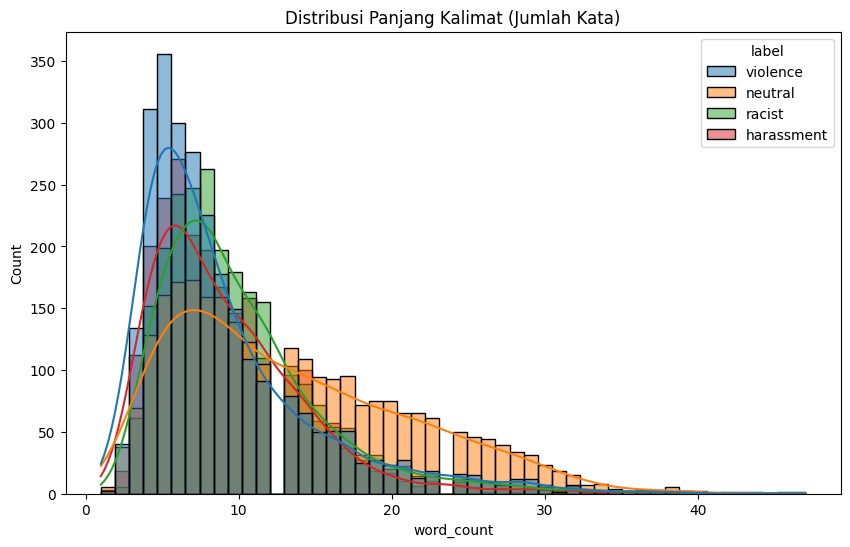

In [14]:
csv['word_count'] = csv['chat'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(10, 6))
sns.histplot(data=csv, x='word_count', hue='label', kde=True, bins=50)
plt.title('Distribusi Panjang Kalimat (Jumlah Kata)')
plt.show()

In [15]:
# 5. Word Frequency (Kata Paling Sering di Toksik)
# (Simple tokenizer, pisahkan spasi)
# toxic_df = df[df['label'] == 1] # Asumsi 1 = Toxic
all_toxic_text = " ".join(toxic['chat'])

In [16]:
print(all_toxic_text)

main mu kek tai cok user telat ngasih tau elu edan sarap gue bergaul elu user user aku\n\nku tau matamu sipit diliat capek deh ketemu kaum cina kapir gini match skill cacad ngide jungler cok user enak lg klo smbil ngewe gw jari lu sebelom gw ukur nyali bacot lu \xf0\x9f\x98\x8f user user user user banci kaleng malu ga 2 nyungsep koe user url kalo belajar ekonomi mestinya jago memprivatisasi hati orang duh ironi user maennya goblok banget sih geblek banget dah bu guru enakan jablay guru esde sih\nkayaknya menikmati pecun guru minum tuh kencing onta emang dasar otak onta dasar anak babi kau cowo gentle kalo ga gentle namanya banci anak anjing goblok banget sih mainnya gitu aja kalah mulu mbak ki gatel lonte cowokku ikuti sange si si user kerjaannya delay mulu setan mainmu noob banget ga bagusnya mah sdh neneknenek sy heran kaum cebong bisanya bohong parah lo mainnya mati aja liat tuh anjing jawa babi cina jalan bareng user gak kak emak mah gak demen ama sipit wkwk kelakuan homok jaman no

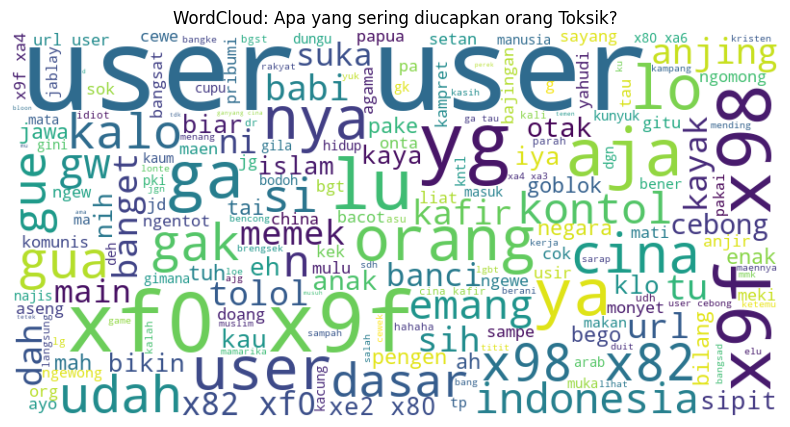

In [17]:
# Bikin WordCloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_toxic_text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('WordCloud: Apa yang sering diucapkan orang Toksik?')
plt.show()

In [18]:
words = all_toxic_text.split()
word_counts = Counter(words)
print("\n--- Top 20 Kata di Label Toksik ---")
print(word_counts.most_common(20))


--- Top 20 Kata di Label Toksik ---
[('user', 4658), ('cina', 851), ('yg', 751), ('ga', 707), ('lu', 641), ('aja', 630), ('ya', 527), ('orang', 515), ('lo', 470), ('dasar', 428), ('nya', 420), ('si', 352), ('udah', 333), ('gua', 310), ('gak', 305), ('kalo', 298), ('kontol', 289), ('url', 285), ('babi', 279), ('gue', 278)]


In [19]:
# https://github.com/okkyibrohim/id-multi-label-hate-speech-and-abusive-language-detection/blob/master/new_kamusalay.csv

# seperating classes

In [20]:
violence = csv[csv["label"] == "violence"]

In [21]:
violence

,id,chat,label,group,word_count
0,1,main mu kek tai cok,violence,Toxic,5
1,2,user telat ngasih tau elu edan sarap gue berga...,violence,Toxic,10
5,6,skill cacad ngide jungler cok,violence,Toxic,5
10,11,gw jari lu sebelom gw ukur nyali bacot lu \xf0...,violence,Toxic,10
12,13,kalo belajar ekonomi mestinya jago memprivatis...,violence,Toxic,11
...,...,...,...,...,...
10514,10515,tolol dah ditungguin bgst,violence,Toxic,4
10533,10534,diem ga sih 4nj1n9,violence,Toxic,4
10548,10549,user user user congor nya dedemit,violence,Toxic,6
10637,10638,dasar fan kampang,violence,Toxic,3


In [22]:
violence_chats = violence.chat

In [23]:
violence_chats

0                                      main mu kek tai cok
1        user telat ngasih tau elu edan sarap gue berga...
5                            skill cacad ngide jungler cok
10       gw jari lu sebelom gw ukur nyali bacot lu \xf0...
12       kalo belajar ekonomi mestinya jago memprivatis...
                               ...                        
10514                            tolol dah ditungguin bgst
10533                                   diem ga sih 4nj1n9
10548                    user user user congor nya dedemit
10637                                    dasar fan kampang
10701                user user congor kamu layak di neraka
Name: chat, Length: 2700, dtype: object

In [24]:
# violence_chats.to_csv("violence_data_chats.csv")

In [25]:
harrasment = csv[csv["label"] == "harassment"]
harrasment_chats = harrasment.chat
# harrasment_chats.to_csv("harrasment_data_chats.csv")

In [26]:
racist = csv[csv["label"] == "racist"]
racist_chats = racist.chat
# racist_chats.to_csv("racist_data_chats.csv")

In [27]:
neutral = csv[csv["label"] == "neutral"]
neutral_chats = neutral.chat
# neutral_chats.to_csv("neutral_data_chats.csv")

In [28]:
neutral_chats

2        kadang berfikir percaya tuhan jatuh berkalikal...
6                                     gg main lo keren bro
7        gue aja kelar rewatch aldnoah zero kampret ema...
8        admin belanja port terbaik nak makan ai kepal ...
16                                 fikiran ampas banget ya
                               ...                        
10668    nyuciin piring org jijik krn mrk makannya ga b...
10672    user user caplok ind beli saham 51 seharga rp5...
10675    perhatian\nada kelompok menggarap film komedi ...
10677       panggil mamih papih diajak komitmen lari cuaks
10700    Fenomena nation branding korea selatan melalui...
Name: chat, Length: 2684, dtype: object